<a href="https://colab.research.google.com/github/vanecornejo/Procesos-Estocasticos/blob/main/Descomposici%C3%B3n%20can%C3%B3nica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Descomposición Canónica**

La descomposición canónica se utiliza para el análisis de cadenas de Markov, organizando la matriz de transición en una forma estructurada que refleje el comportamiento de los estados. Mediante una simple reordenación de filas y columnas, se agrupan los estados con características similares, lo que permite distinguir claramente entre aquellos que pueden abandonarse y aquellos que forman parte del comportamiento estable del sistema.

De esta manera, vamos a analizar la matriz

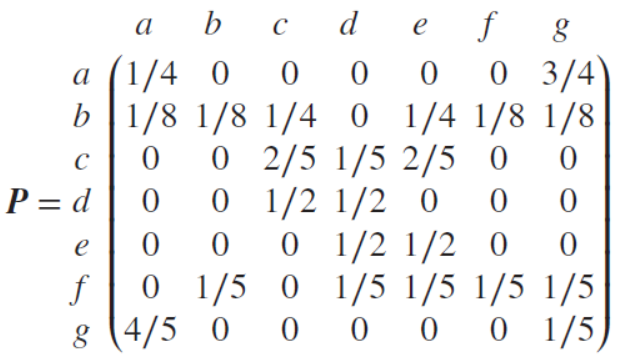

para así determinar si la matriz tiene o no distribución límite. Escribiremos la descomposición canónica de la matriz, se determinará el límite de la potencia n-esima y se va a comparar contra las distribuciones límite de las submatrices.

In [2]:
# Importamos librería necesaria

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

Hay que definir la matriz de transición $P$ de la cadena de Markov.

In [8]:
P = np.array([
    [1/4, 0, 0, 0, 0, 0, 3/4],
    [1/8, 1/8, 1/4, 0, 1/4, 1/8, 1/8],
    [0, 0, 2/5, 1/5, 2/5, 0, 0],
    [0, 0, 1/2, 1/2, 0, 0, 0],
    [0, 0, 0, 1/2, 1/2, 0, 0],
    [0, 1/5, 0, 1/5, 1/5, 1/5, 1/5],
    [4/5, 0, 0, 0, 0, 0, 1/5]
])

print(P)

[[0.25  0.    0.    0.    0.    0.    0.75 ]
 [0.125 0.125 0.25  0.    0.25  0.125 0.125]
 [0.    0.    0.4   0.2   0.4   0.    0.   ]
 [0.    0.    0.5   0.5   0.    0.    0.   ]
 [0.    0.    0.    0.5   0.5   0.    0.   ]
 [0.    0.2   0.    0.2   0.2   0.2   0.2  ]
 [0.8   0.    0.    0.    0.    0.    0.2  ]]


## Diagrama de transiciones

Hagamos el gráfico de la cadena de Markov como un grafo dirigido

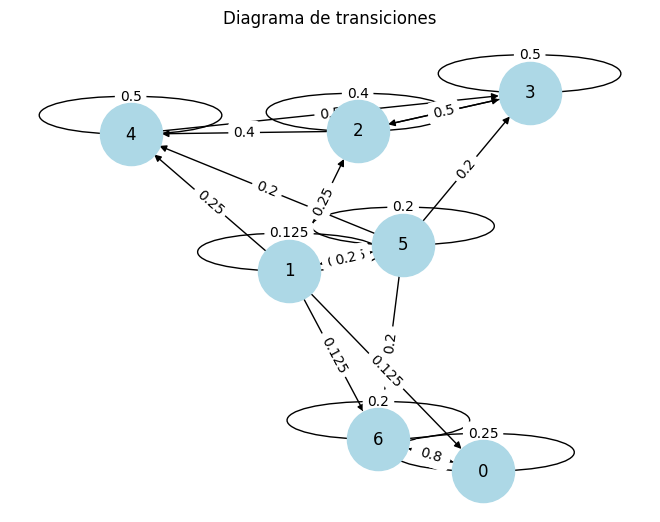

In [ ]:
G = nx.DiGraph()

n = P.shape[0]

for i in range(n):
    for j in range(n):
        if P[i,j] > 0:
            G.add_edge(i, j, weight=P[i,j])

pos = nx.spring_layout(G)

nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000)
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

plt.title("Diagrama de transiciones")
plt.show()

## Distribución límite

Una cadena tiene distribución límite si:

- Es irreducible
- Es aperiódica

También puede analizarse mediante el comportamiento de $P^n$.

In [ ]:
def potencia_matriz(P, n):
    return np.linalg.matrix_power(P, n)

for k in [10, 50, 100]:
    print(f"P^{k} =\n", potencia_matriz(P, k), "\n")

P^10 =
 [[5.17354654e-01 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 4.82645346e-01]
 [1.71988655e-01 5.05661935e-06 2.22173674e-01 2.66708044e-01
  1.77778207e-01 5.05661935e-06 1.61341307e-01]
 [0.00000000e+00 0.00000000e+00 3.33311717e-01 4.00040656e-01
  2.66647628e-01 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 3.33309535e-01 3.99973623e-01
  2.66716842e-01 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 3.33396053e-01 3.99988745e-01
  2.66615203e-01 0.00000000e+00 0.00000000e+00]
 [1.72401722e-01 8.09059095e-06 2.22208834e-01 2.66664126e-01
  1.77782920e-01 8.09059095e-06 1.60926218e-01]
 [5.14821702e-01 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 4.85178298e-01]] 

P^50 =
 [[5.16129032e-01 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 4.83870968e-01]
 [1.72043011e-01 1.51075730e-25 2.22222222e-01 2.66666667e-01
  1.77777778e-01 1.51075730e-25 1.61290

Si las filas de $P^n$ convergen a un mismo vector, entonces existe distribución límite.

En caso contrario, la cadena no tiene distribución límite única.

## Descomposición canónica

Se identifican:

- Estados recurrentes (clases cerradas)
- Estados transitorios

In [ ]:
def clases_comunicacion(P):
    n = len(P)
    G = nx.DiGraph()

    for i in range(n):
        for j in range(n):
            if P[i,j] > 0:
                G.add_edge(i,j)

    return list(nx.strongly_connected_components(G))

clases = clases_comunicacion(P)
clases

[{0, 6}, {2, 3, 4}, {1, 5}]

Las clases obtenidas permiten identificar:

- Clases cerradas → recurrentes
- Clases abiertas → transitorias

In [ ]:
def forma_canonica(P):
    clases = clases_comunicacion(P)

    transitorios = []
    recurrentes = []

    for c in clases:
        cerrado = True
        for i in c:
            for j in range(len(P)):
                if j not in c and P[i,j] > 0:
                    cerrado = False
        if cerrado:
            recurrentes.extend(list(c))
        else:
            transitorios.extend(list(c))

    nuevo_orden = transitorios + recurrentes

    P_canonica = P[np.ix_(nuevo_orden, nuevo_orden)]

    return P_canonica, nuevo_orden

P_can, orden = forma_canonica(P)

P_can, orden

(array([[0.125, 0.125, 0.125, 0.125, 0.25 , 0.   , 0.25 ],
        [0.2  , 0.2  , 0.   , 0.2  , 0.   , 0.2  , 0.2  ],
        [0.   , 0.   , 0.25 , 0.75 , 0.   , 0.   , 0.   ],
        [0.   , 0.   , 0.8  , 0.2  , 0.   , 0.   , 0.   ],
        [0.   , 0.   , 0.   , 0.   , 0.4  , 0.2  , 0.4  ],
        [0.   , 0.   , 0.   , 0.   , 0.5  , 0.5  , 0.   ],
        [0.   , 0.   , 0.   , 0.   , 0.   , 0.5  , 0.5  ]]),
 [1, 5, 0, 6, 2, 3, 4])

La matriz en forma canónica queda organizada como:

$$
P =
\begin{pmatrix}
Q & R \\
0 & I
\end{pmatrix}
$$

donde:

- $Q$: estados transitorios
- $I$: clases recurrentes

In [ ]:
for k in [50, 100, 200]:
    print(f"P^{k} =\n", np.linalg.matrix_power(P_can, k), "\n")

P^50 =
 [[1.51075730e-25 1.51075730e-25 1.72043011e-01 1.61290323e-01
  2.22222222e-01 2.66666667e-01 1.77777778e-01]
 [2.41721168e-25 2.41721168e-25 1.72043011e-01 1.61290323e-01
  2.22222222e-01 2.66666667e-01 1.77777778e-01]
 [0.00000000e+00 0.00000000e+00 5.16129032e-01 4.83870968e-01
  0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 5.16129032e-01 4.83870968e-01
  0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  3.33333333e-01 4.00000000e-01 2.66666667e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  3.33333333e-01 4.00000000e-01 2.66666667e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  3.33333333e-01 4.00000000e-01 2.66666667e-01]] 

P^100 =
 [[5.93420780e-50 5.93420780e-50 1.72043011e-01 1.61290323e-01
  2.22222222e-01 2.66666667e-01 1.77777778e-01]
 [9.49473248e-50 9.49473248e-50 1.72043011e-01 1.61290323e-01
  2.22222222e-01 2.66666667e-01 1.7777

## Conclusiones

Se identificaron las clases de la cadenae, se determinó si existe distribución límite, se obtuvo la forma canónica y se verificó el comportamiento de $P^n$.

Esto permite entender la estabilidad de la cadena de Markov.